# Supervised Machine Learning Project

## Business Problem : “Predict energy consumption in a steel manufacturing plant to optimize electricity usage and reduce operational costs”

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# importing libaries

In [2]:
df = pd.read_csv("Steel_industry_data.csv")
#load the dataset

In [3]:
df.head()
# display top 5 rows

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [4]:
df.shape #shape of the dataset

(35040, 11)

## Data Cleaning

In [5]:
df.isnull().sum() # check with missing values

date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

In [6]:
df.duplicated().sum() # check with duplicate values

np.int64(0)

In [7]:
df = df.drop("Load_Type", axis=1)
# Dropping Load_Type because it derived from energy consumption and could cause data leakage risk.

In [8]:
df = df.drop("CO2(tCO2)",axis=1)
# Dropping CO2(tCO2) because its Carbon emission energy usage and not used for energy prediction usage

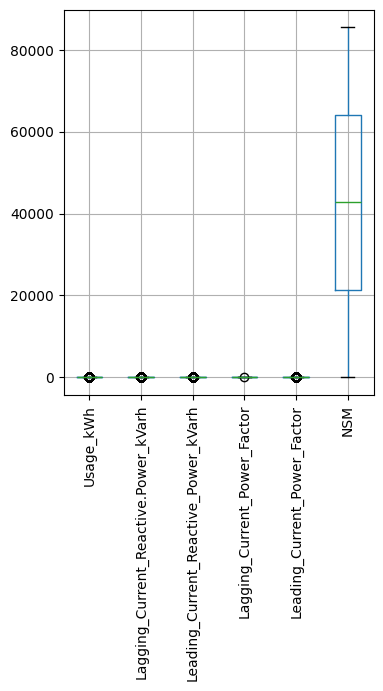

In [9]:
df.boxplot(figsize=(4,5))
plt.xticks(rotation=90)
plt.show()
# boxplot helps in detecting outliers

In [10]:
# Detecting outliers using IQR for better understanding of the detail number of outliers and they lower,upper bound values
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print("-------",col,"-------")
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Outliers:", outliers.shape[0])


------- Usage_kWh -------
Lower Bound: -68.85624999999999
Upper Bound: 123.29374999999999
Number of Outliers: 328
------- Lagging_Current_Reactive.Power_kVarh -------
Lower Bound: -28.209999999999997
Upper Bound: 53.15
Number of Outliers: 1059
------- Leading_Current_Reactive_Power_kVarh -------
Lower Bound: -3.135
Upper Bound: 5.225
Number of Outliers: 7759
------- Lagging_Current_Power_Factor -------
Lower Bound: 9.766250000000007
Upper Bound: 152.57625
Number of Outliers: 1
------- Leading_Current_Power_Factor -------
Lower Bound: 99.25
Upper Bound: 100.44999999999999
Number of Outliers: 8327
------- NSM -------
Lower Bound: -42750.0
Upper Bound: 128250.0
Number of Outliers: 0


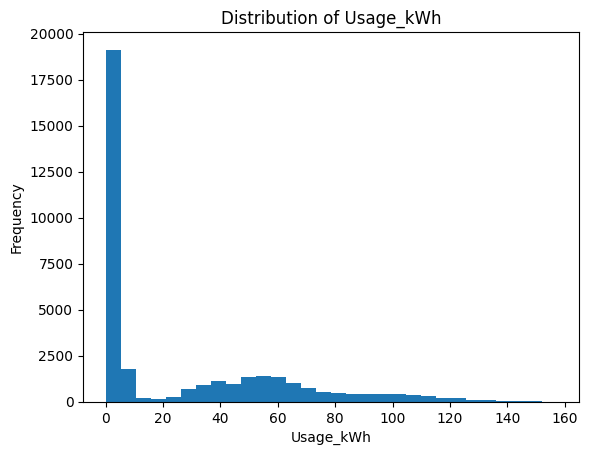

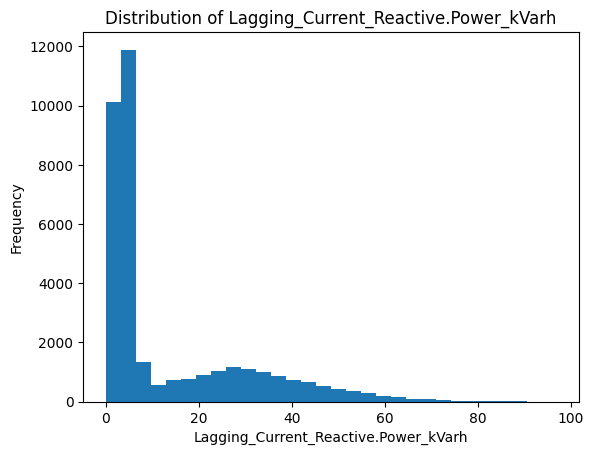

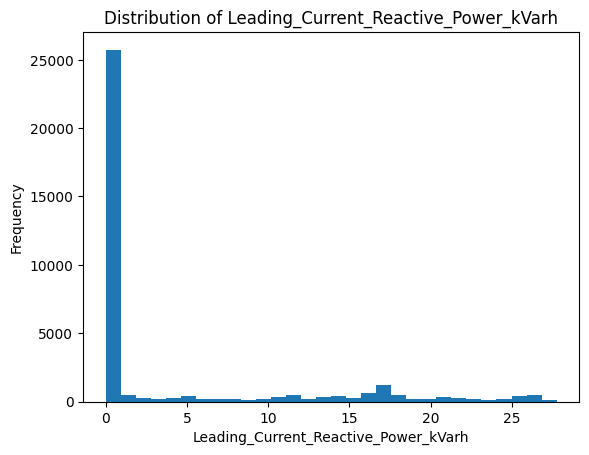

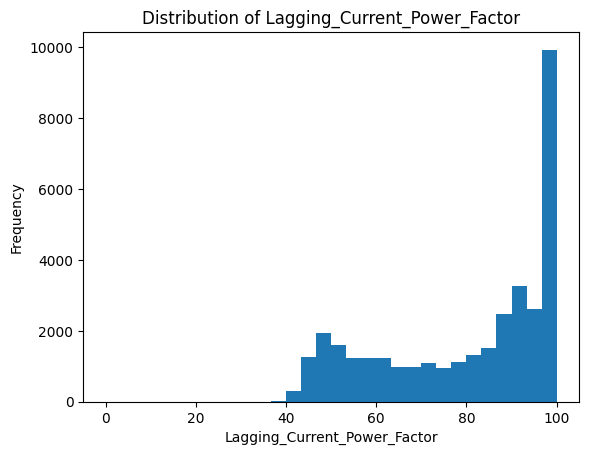

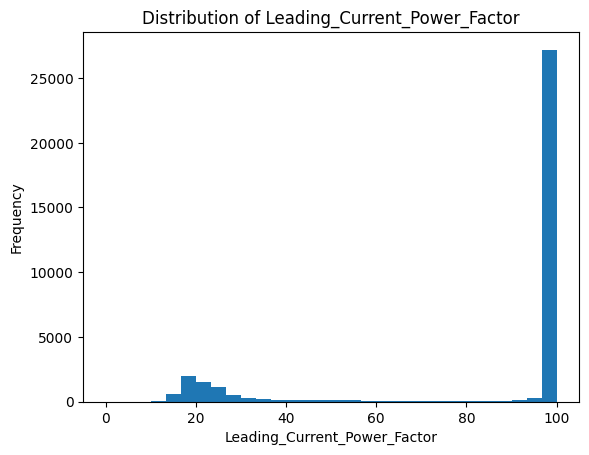

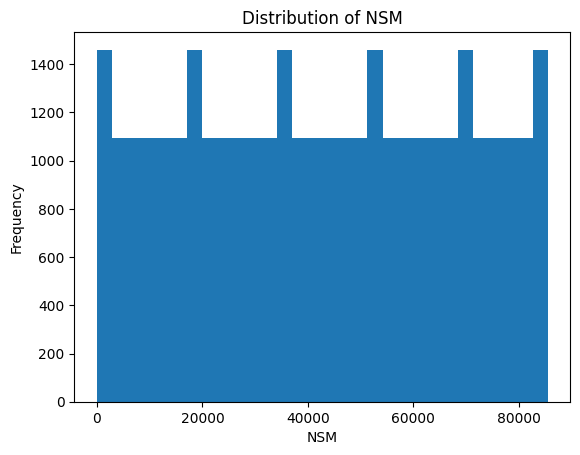

In [11]:
#Plot Historgram for understanding the data distribution shape of each feature
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [12]:
# Outlier Analysis
# Usage_kWh: Contains only 24 outliers, which is minimal. Instead of removing them, capping was applied to preserve data while reducing the impact of extreme values.

# Lagging_Current_Reactive.Power_kVarh:Around 1003 outliers were detected. Since this is a moderate number, capping was used to handle extreme values without losing important information.

# Leading_Current_Reactive_Power_kVarh: Around 7543 outliers were detected. This is due to skewed distribution and presence of many low/zero values. These were not treated as true outliers, so the feature was left unchanged.

# Lagging_Current_Power_Factor: Only 1 outlier was detected, which is negligible and safely ignored.

# Leading_Current_Power_Factor: Around 8248 outliers were identified due to tight clustering of values near 100, so the feature was retained as is.

# NSM (Number of Seconds from Midnight):No outliers were detected, as expected for a time-based feature.

In [13]:
# Capping Usage_kWh, Lagging_Current_Reactive.Power_kVarh Feature
cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

In [14]:
# NSM has huge range from 0 to 86400 (seconds in a day) .
# We used sine and cosine transformation on NSM because it represents time of day, which is cyclical in nature, and 
# sin/cos helps preserve this circular relationship.

In [15]:
df["NSM_sin"] = np.sin(2 * np.pi * df["NSM"] / 86400)
df["NSM_cos"] = np.cos(2 * np.pi * df["NSM"] / 86400)

In [16]:
df.drop("NSM", axis=1, inplace=True) 
# droping the original NSM column since we have gOT NSM_sin and NSM_cos columns

In [17]:
#Converting date format and dividing it in day and month
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y %H:%M")
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df.drop("date", axis=1, inplace=True)

In [18]:
# Month cyclical 
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df.drop("month", axis=1, inplace=True)

In [19]:
y = df["Usage_kWh"] # target varaible

In [20]:
X = df.drop(["Usage_kWh"],axis=1) # input features

In [21]:
# splitting the data into training and testing
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
num_cols = X.select_dtypes(["int64","float64","int32"]).columns
print(num_cols)
# Numerical columns from the dataset

Index(['Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor',
       'Leading_Current_Power_Factor', 'NSM_sin', 'NSM_cos', 'day',
       'month_sin', 'month_cos'],
      dtype='object')


In [23]:
cat_cols = X.select_dtypes(["object","bool"]).columns
print(cat_cols)
# Categorical columns from the dataset

Index(['WeekStatus', 'Day_of_week'], dtype='object')


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Usage_kWh                             35040 non-null  float64
 1   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 2   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 3   Lagging_Current_Power_Factor          35040 non-null  float64
 4   Leading_Current_Power_Factor          35040 non-null  float64
 5   WeekStatus                            35040 non-null  object 
 6   Day_of_week                           35040 non-null  object 
 7   NSM_sin                               35040 non-null  float64
 8   NSM_cos                               35040 non-null  float64
 9   day                                   35040 non-null  int32  
 10  month_sin                             35040 non-null  float64
 11  month_cos      

# KNN Regressor

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
# Preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols), #Standard scaler because equal important to all features ,works for low outliers
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols) # Onehot encoding because it convert them into numbers without meaning distortion(no order)
])
# Pipeline
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor())
])

In [26]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [3, 5, ...], 'model__p': [1, 2], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [30]:
# for knn i used grid search cv because it has Small parameter space and works faster

In [27]:
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'model__n_neighbors': 5, 'model__p': 2, 'model__weights': 'distance'}
Best Score: 0.9696201354957635


In [28]:
y_pred = grid.predict(X_test)
y_pred_train = grid.predict(X_train)

In [29]:
from sklearn.metrics import r2_score
print("K NEAREST NEIGHBORS REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred))
print("R2 Score training:", r2_score(y_train, y_pred_train))

K NEAREST NEIGHBORS REGRESSION
R2 Score testing: 0.9718002228353312
R2 Score training: 0.9999999999999982


In [30]:
# Model is performing very well, but slightly overfitting

# Decision Tree Regression

In [32]:
from sklearn.tree import DecisionTreeRegressor
pipe1 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

In [33]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    "model__max_depth": [3, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}
tree_cv = RandomizedSearchCV(pipe1, param_grid, cv=5, n_jobs=-1)
tree_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.

In [34]:
# for decision tree i used RandomizedSearch because is faster and avoids overfitting from brute force grid

In [35]:
print("Best Params:", tree_cv.best_params_)
print("Best CV Score:", tree_cv.best_score_)

Best Params: {'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 10}
Best CV Score: 0.993822366112657


In [36]:
y_pred = tree_cv.predict(X_test)
y_pred_train = tree_cv.predict(X_train)

In [37]:
from sklearn.metrics import r2_score
print("DECISION TREE REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred))
print("R2 Score training:", r2_score(y_train, y_pred_train))

DECISION TREE REGRESSION
R2 Score testing: 0.9946406337222995
R2 Score training: 0.99654389111375


In [38]:
# Extremely high accuracy ie model fits data very well

# Linear Regression

In [40]:
# for linear regression we dont tune it beacause It has NO real hyperparameters.

In [43]:
# we can only tune linear regression using Ridge and lasso 

In [91]:
from sklearn.linear_model import Ridge,Lasso
pipe_ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())])

In [94]:
param_grid = {
    "regressor__alpha": [0.01, 0.1, 1, 10, 100]
}
ridge_cv = GridSearchCV(pipe_ridge,param_grid,cv=5,scoring="r2",verbose=1)
ridge_cv.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...r', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and ca

In [95]:
print("Best Params:", ridge_cv.best_params_)
print("Best CV:", ridge_cv.best_score_)

Best Params: {'regressor__alpha': 1}
Best CV: 0.9170659691839201


In [96]:
y_pred = ridge_cv.predict(X_test)
y_pred_train = ridge_cv.predict(X_train)

In [97]:
print("RIDGE LINEAR REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred))
print("R2 Score training:", r2_score(y_train, y_pred_train))

RIDGE LINEAR REGRESSION
R2 Score testing: 0.9143896867700012
R2 Score training: 0.9171908788455387


In [99]:
# Lasso Regression
pipe_lasso = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso())])

In [101]:
param_grid = {
    "regressor__alpha": [0.001, 0.01, 0.1, 1]
}
lasso_cv = GridSearchCV(pipe_lasso, param_grid, cv=5, scoring="r2",verbose=1)
lasso_cv.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...r', Lasso())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and 

In [102]:
print("Best Params:", lasso_cv.best_params_)
print("Best CV:", lasso_cv.best_score_)

Best Params: {'regressor__alpha': 0.001}
Best CV: 0.9170658384605568


In [103]:
y_pred_lasso = lasso_cv.predict(X_test)
y_pred_lasso_train = lasso_cv.predict(X_train)

In [104]:
print("LASSO LINEAR REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred_lasso))
print("R2 Score training:", r2_score(y_train, y_pred_lasso_train))

LASSO LINEAR REGRESSION
R2 Score testing: 0.914388892307478
R2 Score training: 0.9171907980702588


# Random Forest Regression

In [50]:
from sklearn.ensemble import RandomForestRegressor
pipe3 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [51]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': [None, 'sqrt', 'log2']
}
rf_cv = RandomizedSearchCV(pipe3, param_grid, cv=5, n_jobs=-1,scoring='r2',verbose=1)
rf_cv.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': [None, 'sqrt', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation st

In [53]:
# for random forest i have used RandomizedSearchCV because it has Large hyperparameter space 

In [52]:
print("Best Params:", rf_cv.best_params_)
print("Best CV Score:", rf_cv.best_score_)

Best Params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': 20}
Best CV Score: 0.9972652357997532


In [54]:
y_pred = rf_cv.predict(X_test)
y_pred_train = rf_cv.predict(X_train)

In [56]:
print("RANDOM FOREST REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred))
print("R2 Score training:", r2_score(y_train, y_pred_train))

RANDOM FOREST REGRESSION
R2 Score testing: 0.9975861181337049
R2 Score training: 0.9989188841344878


In [57]:
# Model showing excellent predictive accuracy and almost perfect generalization on unseen data.

# ADA BOOSTING REGRESSOR

In [58]:
from sklearn.ensemble import AdaBoostRegressor
base_tree = DecisionTreeRegressor(random_state=42)

pipe4 = Pipeline([
    ('preprocessor', preprocessor),
    ('ada', AdaBoostRegressor(estimator=base_tree,random_state=42))
])

In [59]:
param_grid = {
    'ada__n_estimators': [50, 100, 200],
    'ada__learning_rate': [0.01, 0.1, 0.5],
    'ada__estimator__max_depth': [2, 3, 4]
}
ada_cv = GridSearchCV(pipe4, param_grid, cv=5, n_jobs=-1,scoring='r2',verbose=1)
ada_cv.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ada__estimator__max_depth': [2, 3, ...], 'ada__learning_rate': [0.01, 0.1, ...], 'ada__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [60]:
# for ada boosting regressor used grid search cv because it has small parameter space

In [61]:
print("Best Params:", ada_cv.best_params_)
print("Best CV Score:", ada_cv.best_score_)

Best Params: {'ada__estimator__max_depth': 4, 'ada__learning_rate': 0.5, 'ada__n_estimators': 50}
Best CV Score: 0.9813880283165931


In [62]:
y_pred = ada_cv.predict(X_test)
y_pred_train = ada_cv.predict(X_train)

In [63]:
print("ADA BOOSTIONG REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred))
print("R2 Score training:", r2_score(y_train, y_pred_train))

ADA BOOSTIONG REGRESSION
R2 Score testing: 0.9824307137172003
R2 Score training: 0.982517128791783


In [64]:
# model is indicating good generalization with minimal overfitting

# GRADIENT DESCANT REGRESSION

In [65]:
from sklearn.linear_model import SGDRegressor
pipe5 = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", SGDRegressor(random_state=42))
])

In [66]:
param_grid = {
    'regressor__alpha': [0.0001, 0.001, 0.01],
    'regressor__penalty': ['l2', 'l1', 'elasticnet'],
    'regressor__learning_rate': ['constant', 'adaptive'],
    'regressor__eta0': [0.001, 0.01, 0.1],
    'regressor__max_iter': [1000, 1500],
    'regressor__tol': [1e-3, 1e-4]
}
gd_cv = GridSearchCV(pipe5, param_grid, cv=5, n_jobs=-1,scoring='r2',verbose=1)
gd_cv.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': [0.0001, 0.001, ...], 'regressor__eta0': [0.001, 0.01, ...], 'regressor__learning_rate': ['constant', 'adaptive'], 'regressor__max_iter': [1000, 1500], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.-

In [68]:
# for Stochastic gradient descant i have used grid search cv because its a sensitive model and has few but important parameters

In [67]:
print("Best Params:", gd_cv.best_params_)
print("Best CV Score:", gd_cv.best_score_)

Best Params: {'regressor__alpha': 0.01, 'regressor__eta0': 0.001, 'regressor__learning_rate': 'adaptive', 'regressor__max_iter': 1000, 'regressor__penalty': 'l1', 'regressor__tol': 0.0001}
Best CV Score: 0.9170710721743542


In [69]:
y_pred = gd_cv.predict(X_test)
y_pred_train = gd_cv.predict(X_train)

In [71]:
print("STOCHASTIC GRADIENT DESCANT REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred))
print("R2 Score training:", r2_score(y_train, y_pred_train))

STOCHASTIC GRADIENT DESCANT REGRESSION
R2 Score testing: 0.9143673665057342
R2 Score training: 0.9171839588909498


In [72]:
# Model is indicating a simpler linear fit that generalizes well but cannot capture complex non-linear patterns in the data.

# XG BOOSTING REGRESSION

In [73]:
from xgboost import XGBRegressor
pipe6 = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(objective='reg:squarederror',random_state=42))
])

In [74]:
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__subsample': [0.7, 0.8, 1.0],
    'regressor__colsample_bytree': [0.7, 0.8, 1.0]
}
xg_cv = RandomizedSearchCV(pipe6, param_grid, cv=5, n_jobs=-1,scoring='r2',verbose=1)
xg_cv.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__colsample_bytree': [0.7, 0.8, ...], 'regressor__learning_rate': [0.01, 0.05, ...], 'regressor__max_depth': [3, 5, ...], 'regressor__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscro

In [76]:
# for xg boosting used randomizedsearch because it has many hyperparamters and has high risk of overfitting

In [75]:
print("Best Params:", xg_cv.best_params_)
print("Best CV Score:", xg_cv.best_score_)

Best Params: {'regressor__subsample': 0.8, 'regressor__n_estimators': 300, 'regressor__max_depth': 5, 'regressor__learning_rate': 0.1, 'regressor__colsample_bytree': 1.0}
Best CV Score: 0.9971950141268074


In [95]:
y_pred = xg_cv.predict(X_test)
y_pred_train = xg_cv.predict(X_train)

In [96]:
print("XG BOOSTING REGRESSION")
print("R2 Score testing:", r2_score(y_test, y_pred))
print("R2 Score training:", r2_score(y_train, y_pred_train))

XG BOOSTING REGRESSION
R2 Score testing: 0.997691224411678
R2 Score training: 0.9995808485561872


In [77]:
# model is indicating extremely high predictive power with excellent overall generalization.

# BEST MODEL R2 SCORE

In [105]:
modelss = {
    "KNeighborRegressor":grid,
    "DecisionTreeRegreesor":tree_cv,
    "RidgeRegression":ridge_cv,
    "LassoRegression":lasso_cv,
    "RandomForestRegressor":rf_cv,
    "AdaBoostingRegressor":ada_cv,
    "SGDRegressor": gd_cv,
    "XGBoostRegressor": xg_cv
}

In [107]:
r2_scores = {}

for name, model in modelss.items():
    r2_scores[name] = model.best_score_

In [108]:
best_model_name = max(r2_scores, key=r2_scores.get)
best_r2 = r2_scores[best_model_name]

print("Best Model:", best_model_name)
print("Best R2 Score:", best_r2)

Best Model: RandomForestRegressor
Best R2 Score: 0.9972652357997532


In [109]:
import pickle
with open("Best_model.pkl", "wb") as file:
    pickle.dump(rf_cv, file)

print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl


In [6]:
import warnings
warnings.filterwarnings('ignore')